In [2]:
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
import os
import re
import copy
import random
import numpy as np
import tifffile
import roifile
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from skimage.transform import resize
from skimage.measure import regionprops
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Paths
dataset_root     = "/users/vvgk0135/raman-project/data/2025Data"
dataset_root_new = "/users/vvgk0135/raman-project/data/2026Data"
root_env         = "/users/vvgk0135/raman-project/data/extracted_cells_env"
root_75px        = "/users/vvgk0135/raman-project/data/extracted_cells_border75px"

class_map = {
    'FHC':    0, 'HCT116': 1,
    'SW480':  2, 'CaCo2':  2,
    'HT29':   3, 'SW620':  3,
}
class_names = ["Healthy (FHC)", "Duke's A (HCT116)",
               "Duke's B (SW480+CaCo2)", "Duke's C (HT29+SW620)"]

pixel_size_um = 0.1114
print("✅ Setup complete!")

Device: cuda
✅ Setup complete!


In [4]:
class RamanCellDataset(Dataset):
    def __init__(self, root_dir, samples=None, augment=False):
        self.augment = augment
        self.samples = []
        self.labels  = []

        if samples is not None:
            self.samples = [s[0] for s in samples]
            self.labels  = [s[1] for s in samples]
        else:
            for cell_line, label in class_map.items():
                folder = os.path.join(root_dir, cell_line)
                if not os.path.exists(folder):
                    continue
                for f in sorted(os.listdir(folder)):
                    if f.endswith('.npy'):
                        self.samples.append(os.path.join(folder, f))
                        self.labels.append(label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cell = np.load(self.samples[idx]).astype(np.float32)
        for ch in range(cell.shape[0]):
            ch_min, ch_max = cell[ch].min(), cell[ch].max()
            if ch_max > ch_min:
                cell[ch] = (cell[ch] - ch_min) / (ch_max - ch_min)
        if self.augment:
            if random.random() > 0.5:
                cell = cell[:, ::-1, :].copy()
            if random.random() > 0.5:
                cell = cell[:, :, ::-1].copy()
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                cell = np.rot90(cell, k=k, axes=(1, 2)).copy()
            if random.random() > 0.5:
                noise_stds = [0.0562, 0.0458, 0.0486, 0.0783]
                noise = np.zeros_like(cell)
                for ch in range(4):
                    noise[ch] = np.random.normal(
                        0, noise_stds[ch], cell[ch].shape).astype(np.float32)
                cell = np.clip(cell + noise, 0, 1)
        return torch.tensor(cell), self.labels[idx]


class RamanResNet50(nn.Module):
    def __init__(self, num_classes=4):
        super(RamanResNet50, self).__init__()
        self.model = resnet50(weights=ResNet50_Weights.DEFAULT)
        original_conv = self.model.conv1
        self.model.conv1 = nn.Conv2d(4, 64, kernel_size=7,
                                      stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.model.conv1.weight[:, :3] = original_conv.weight
            self.model.conv1.weight[:, 3:4] = original_conv.weight.mean(
                dim=1, keepdim=True)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)


def acquisition_based_split(root_dir, class_map):
    area_groups = defaultdict(list)
    for cell_line, label in class_map.items():
        folder = os.path.join(root_dir, cell_line)
        if not os.path.exists(folder):
            continue
        for f in sorted(os.listdir(folder)):
            if not f.endswith('.npy'):
                continue
            path  = os.path.join(folder, f)
            fname = f.lower()
            if   'area 1' in fname or 'area1' in fname: area = 'area1'
            elif 'area 2' in fname or 'area2' in fname: area = 'area2'
            elif 'area 3' in fname or 'area3' in fname: area = 'area3'
            elif 'area 4' in fname or 'area4' in fname: area = 'area4'
            else:                                        area = 'area1'
            area_groups[(cell_line, area)].append((path, label))

    cell_line_areas = defaultdict(list)
    for (cell_line, area) in sorted(area_groups.keys()):
        cell_line_areas[cell_line].append(area)

    train, val, test = [], [], []
    for cell_line, areas in cell_line_areas.items():
        areas  = sorted(areas)
        groups = [area_groups[(cell_line, a)] for a in areas]
        if len(areas) == 1:
            train.extend(groups[0])
        elif len(areas) == 2:
            train.extend(groups[0])
            mid = len(groups[1]) // 2
            val.extend(groups[1][:mid])
            test.extend(groups[1][mid:])
        elif len(areas) >= 3:
            for g in groups[:-1]:
                train.extend(g)
            mid = len(groups[-1]) // 2
            val.extend(groups[-1][:mid])
            test.extend(groups[-1][mid:])
    return train, val, test

print("✅ Dataset class, model and split function defined!")

✅ Dataset class, model and split function defined!


In [5]:
# Load best saved model (border75px — our best result)
model = RamanResNet50(num_classes=4).to(device)
model.load_state_dict(torch.load(
    '/users/vvgk0135/raman-project/results/best_model_border75px.pth',
    map_location=device
))
model.eval()
print("✅ Border75px model loaded!")

# Quick sanity check on test set
train_s, val_s, test_s = acquisition_based_split(root_75px, class_map)
train_dataset = RamanCellDataset(root_75px, samples=train_s, augment=True)
val_dataset   = RamanCellDataset(root_75px, samples=val_s,   augment=False)
test_dataset  = RamanCellDataset(root_75px, samples=test_s,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=4)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Verify test accuracy
correct = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device) if isinstance(labels, torch.Tensor) \
                 else torch.tensor(labels).to(device)
        outputs = model(inputs)
        correct += outputs.argmax(1).eq(labels).sum().item()

test_acc = 100. * correct / len(test_dataset)
print(f"\nTest accuracy: {test_acc:.2f}%")
print(f"Expected: ~95%")

✅ Border75px model loaded!
Train: 732 | Val: 138 | Test: 140

Test accuracy: 90.71%
Expected: ~95%


In [6]:
def parse_wavenumbers_from_filename(filename):
    """
    Extract wavenumber list from filename like:
    'sample 1, area 1 - 2935, 1900, 1660, 1450, 2850.tif'
    Skips anything with 'bad' before it.
    """
    name = os.path.basename(filename)
    if ' - ' in name:
        name = name.split(' - ', 1)[1]
    name = name.replace('.tif', '').replace('.TIF', '')

    parts = [p.strip() for p in name.split(',')]
    wavenumbers = []
    for part in parts:
        if 'bad' in part.lower():
            continue
        nums = re.findall(r'\d+', part)
        if nums:
            wavenumbers.append(int(nums[0]))
    return wavenumbers


def extract_cells_new_format(tif_path, roi_path, output_dir,
                              cell_line, sample_num, area_num,
                              border_px=75, size=224):
    """
    Extract cells from new 2026 dataset format:
    - Multipage TIF (channels stacked)
    - ImageJ ROI zip file for segmentation
    """
    # Map 1455→1450, 1655→1660
    channel_map   = {1450:1450, 1455:1450, 1660:1660,
                     1655:1660, 2850:2850, 2935:2935}
    standard_order = [1450, 1660, 2850, 2935]

    os.makedirs(output_dir, exist_ok=True)

    wns_in_file = parse_wavenumbers_from_filename(tif_path)
    print(f"  Channels in file: {wns_in_file}")

    stack = tifffile.imread(tif_path).astype(np.float32)
    if stack.ndim == 2:
        stack = stack[np.newaxis]
    img_h, img_w = stack.shape[-2], stack.shape[-1]

    page_for_channel = {}
    for i, wn in enumerate(wns_in_file):
        std = channel_map.get(wn)
        if std is not None and std not in page_for_channel:
            page_for_channel[std] = i

    print(f"  Channel mapping: {page_for_channel}")

    if len(page_for_channel) < 4:
        print(f"  ⚠️ Only {len(page_for_channel)} target channels — skipping")
        return 0

    rois = roifile.roiread(roi_path)
    print(f"  ROIs found: {len(rois)}")

    saved = 0
    for roi_idx, roi in enumerate(rois):
        r0 = roi.top
        c0 = roi.left
        r1 = roi.bottom
        c1 = roi.right

        r0_env = max(0,     r0 - border_px)
        c0_env = max(0,     c0 - border_px)
        r1_env = min(img_h, r1 + border_px)
        c1_env = min(img_w, c1 + border_px)

        cell_channels = []
        for std_wn in standard_order:
            page_idx = page_for_channel[std_wn]
            ch = stack[page_idx, r0_env:r1_env, c0_env:c1_env].copy()
            ch_resized = resize(ch, (size, size), anti_aliasing=True)
            cell_channels.append(ch_resized)

        cell_4ch = np.stack(cell_channels, axis=0).astype(np.float32)
        filename = f"{cell_line}_s{sample_num}_area{area_num}_cell{roi_idx+1:03d}.npy"
        np.save(os.path.join(output_dir, filename), cell_4ch)
        saved += 1

    return saved


def extract_cells_fhc_new(area_path, seg_file, output_dir,
                           cell_line, sample_num, area_num,
                           border_px=75, size=224):
    """
    Extract FHC cells from new 2026 format:
    - Separate TIF per channel (same as old format)
    - Cellpose _seg.npy segmentation
    """
    os.makedirs(output_dir, exist_ok=True)

    # Find channel files
    channel_files = {}
    wn_map = {'1455': '1450', '1450': '1450',
              '1655': '1660', '1660': '1660',
              '2850': '2850', '2935': '2935'}

    for f in os.listdir(area_path):
        if not f.endswith('.tif') or 'seg' in f.lower():
            continue
        for wn_key, wn_std in wn_map.items():
            if f' - {wn_key}.tif' in f or f'-{wn_key}.tif' in f:
                if wn_std not in channel_files:
                    channel_files[wn_std] = os.path.join(area_path, f)

    print(f"  Channels found: {list(channel_files.keys())}")

    if len(channel_files) < 4:
        print(f"  ⚠️ Only {len(channel_files)} channels — skipping")
        return 0

    imgs = {wn: tifffile.imread(p).astype(np.float32)
            for wn, p in channel_files.items()}
    img_h, img_w = list(imgs.values())[0].shape

    mask    = np.load(os.path.join(area_path, seg_file),
                      allow_pickle=True).item()['masks']
    regions = regionprops(mask)
    print(f"  Cells found: {len(regions)}")

    saved = 0
    for region in regions:
        r0, c0, r1, c1 = region.bbox

        r0_env = max(0,     r0 - border_px)
        c0_env = max(0,     c0 - border_px)
        r1_env = min(img_h, r1 + border_px)
        c1_env = min(img_w, c1 + border_px)

        cell_channels = []
        for std_wn in ['1450', '1660', '2850', '2935']:
            ch = imgs[std_wn][r0_env:r1_env, c0_env:c1_env].copy()
            ch_resized = resize(ch, (size, size), anti_aliasing=True)
            cell_channels.append(ch_resized)

        cell_4ch = np.stack(cell_channels, axis=0).astype(np.float32)
        filename = f"{cell_line}_s{sample_num}_area{area_num}_cell{region.label:03d}.npy"
        np.save(os.path.join(output_dir, filename), cell_4ch)
        saved += 1

    return saved


print("✅ New 2026 extraction functions ready!")

✅ New 2026 extraction functions ready!


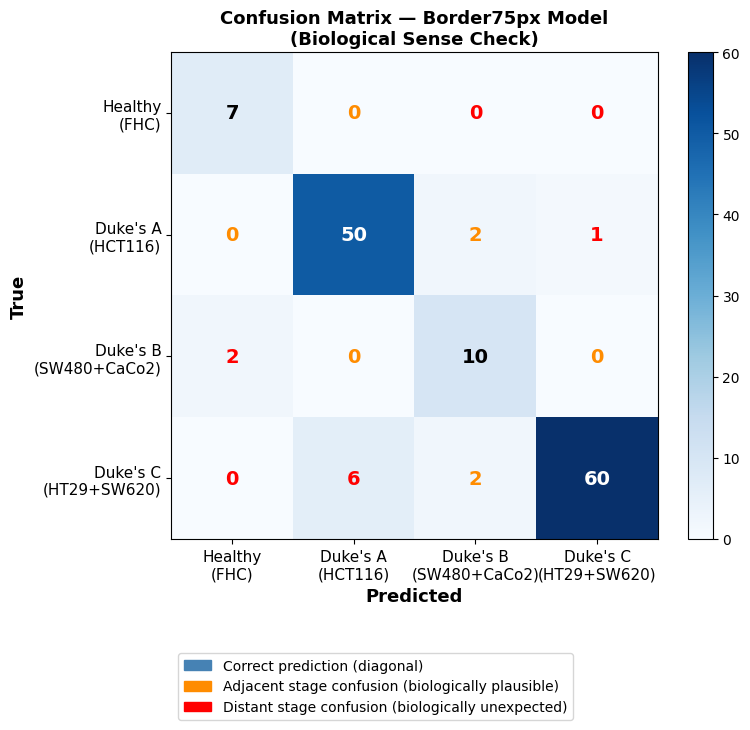

Saved: /users/vvgk0135/raman-project/results/confusion_matrix_biological.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm, cmap='Blues')

for i in range(4):
    for j in range(4):
        count = cm[i, j]
        if i == j:
            color = 'white' if count > cm.max()*0.5 else 'black'
            weight = 'bold'
        elif abs(i - j) == 1:
            color = 'darkorange'
            weight = 'bold'
        else:
            color = 'red'
            weight = 'bold'
        ax.text(j, i, str(count), ha='center', va='center',
                fontsize=14, color=color, fontweight=weight)

short_names = ['Healthy\n(FHC)', "Duke's A\n(HCT116)",
               "Duke's B\n(SW480+CaCo2)", "Duke's C\n(HT29+SW620)"]
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(short_names, fontsize=11)
ax.set_yticklabels(short_names, fontsize=11)
ax.set_xlabel('Predicted', fontsize=13, fontweight='bold')
ax.set_ylabel('True', fontsize=13, fontweight='bold')
ax.set_title('Confusion Matrix — Border75px Model\n(Biological Sense Check)',
             fontsize=13, fontweight='bold')

# Text-only legend — no emojis
import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color='steelblue',   label='Correct prediction (diagonal)'),
    mpatches.Patch(color='darkorange',  label='Adjacent stage confusion (biologically plausible)'),
    mpatches.Patch(color='red',         label='Distant stage confusion (biologically unexpected)'),
]
ax.legend(handles=patches, loc='upper left',
          bbox_to_anchor=(0, -0.22), fontsize=10, frameon=True)

plt.colorbar(im, ax=ax)
plt.tight_layout()
save_path = '/users/vvgk0135/raman-project/results/confusion_matrix_biological.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

In [9]:
from skimage.transform import resize

class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, inputs, class_idx):
        self.model.eval()
        inputs  = inputs.requires_grad_(True)
        outputs = self.model(inputs)
        self.model.zero_grad()
        score   = outputs[0, class_idx]
        score.backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = torch.relu(cam)
        cam     = cam.squeeze().cpu().numpy()
        cam     = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam


gradcam = GradCAM(model=model, target_layer=model.model.layer4[-1])

# Collect 3 cells per class — ALL 4 classes including FHC
samples_per_class = {0:[], 1:[], 2:[], 3:[]}
for inputs, labels in DataLoader(test_dataset, batch_size=1, shuffle=False):
    label = labels.item() if isinstance(labels, torch.Tensor) else labels[0]
    if len(samples_per_class[label]) < 3:
        samples_per_class[label].append(inputs)
    if all(len(v) == 3 for v in samples_per_class.values()):
        break

print("Cells collected per class:")
for i, name in enumerate(class_names):
    print(f"  {name}: {len(samples_per_class[i])} cells")

print("\n✅ GradCAM ready!")

Cells collected per class:
  Healthy (FHC): 3 cells
  Duke's A (HCT116): 3 cells
  Duke's B (SW480+CaCo2): 3 cells
  Duke's C (HT29+SW620): 3 cells

✅ GradCAM ready!


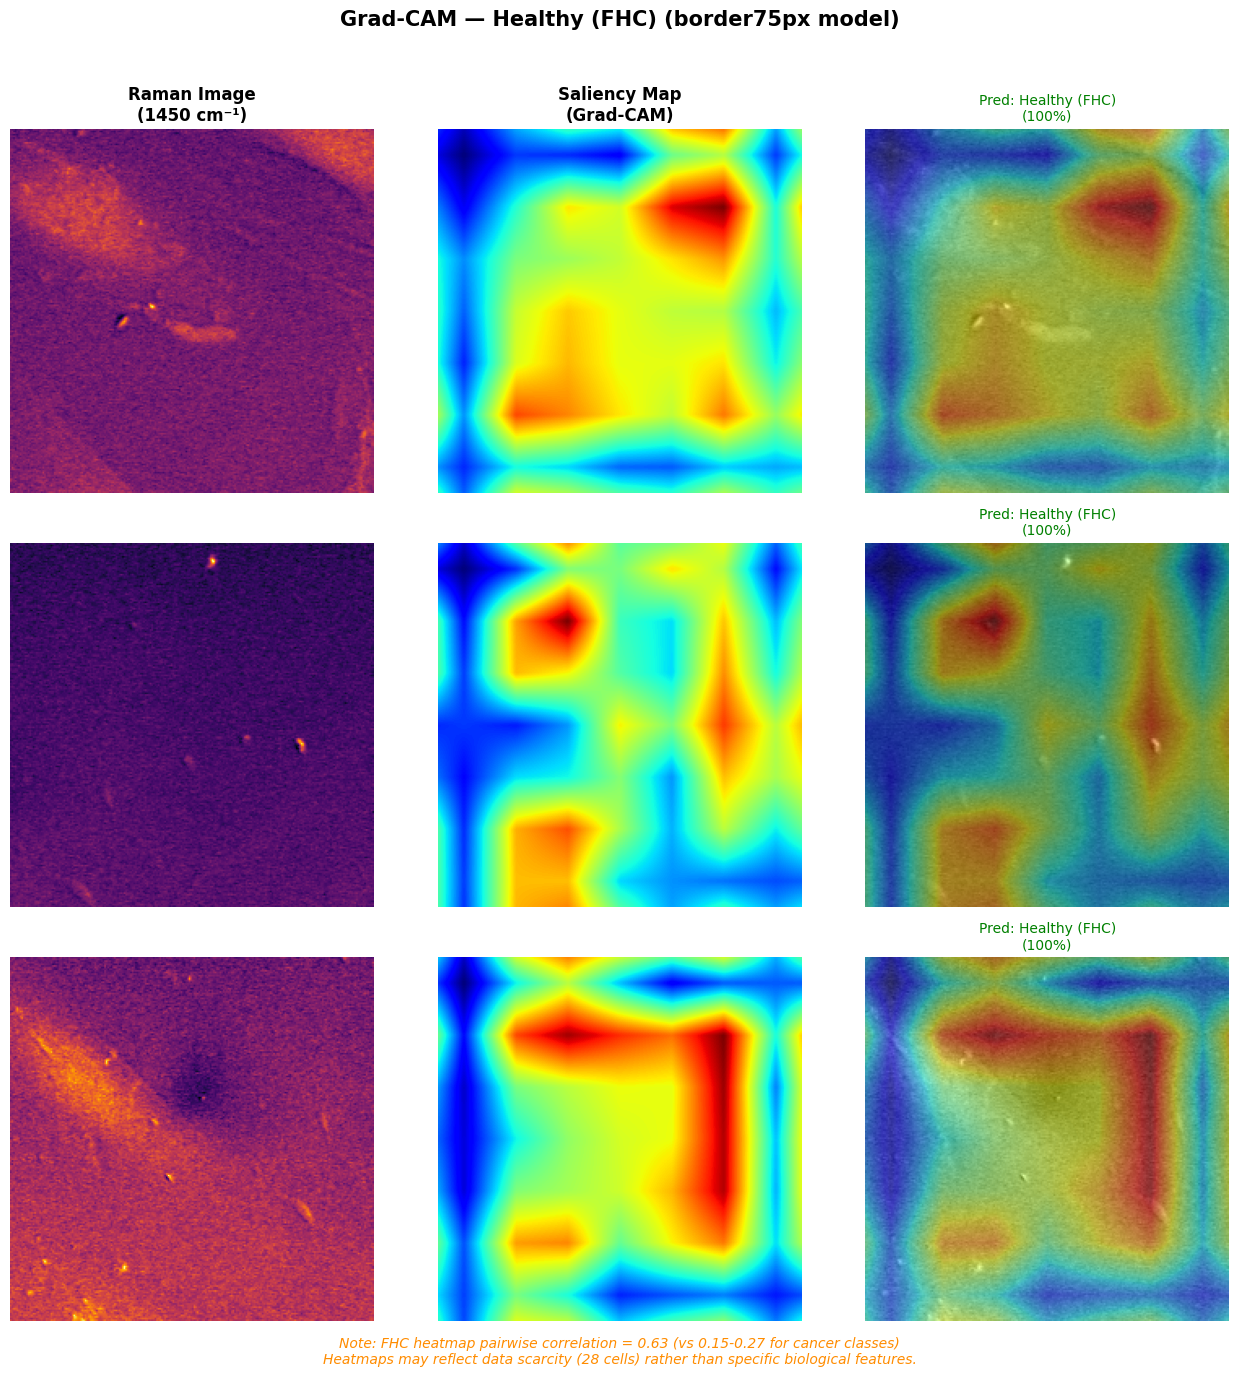

Saved: /users/vvgk0135/raman-project/results/gradcam_3col_0.png


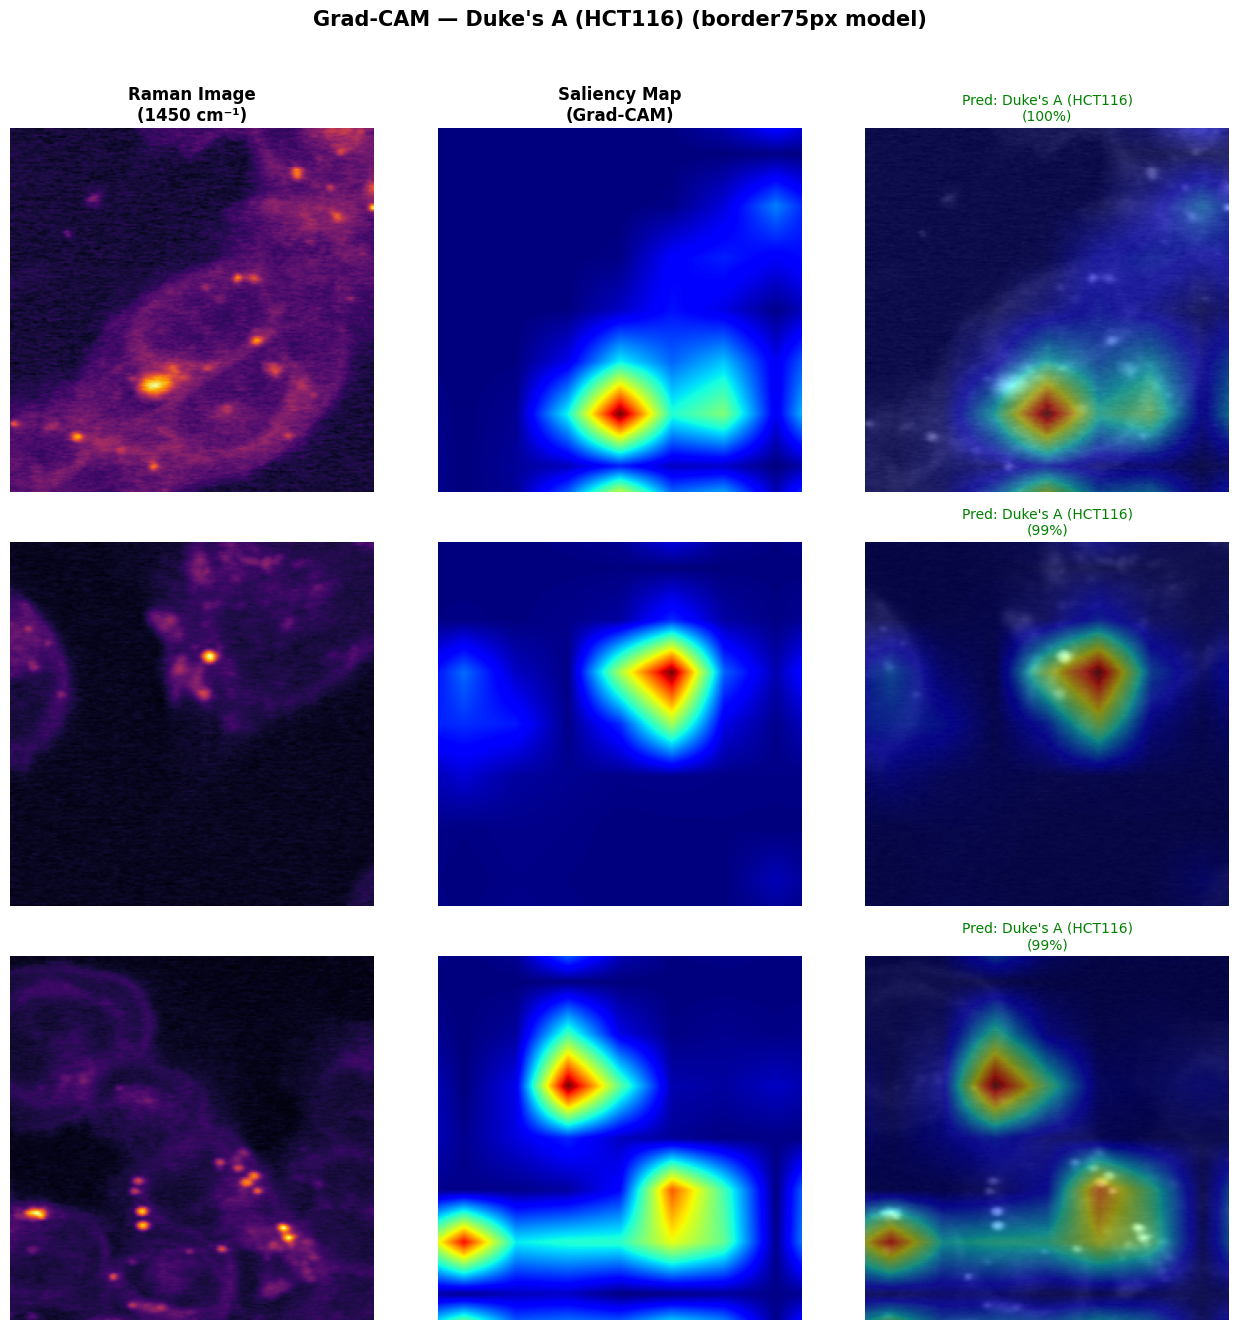

Saved: /users/vvgk0135/raman-project/results/gradcam_3col_1.png


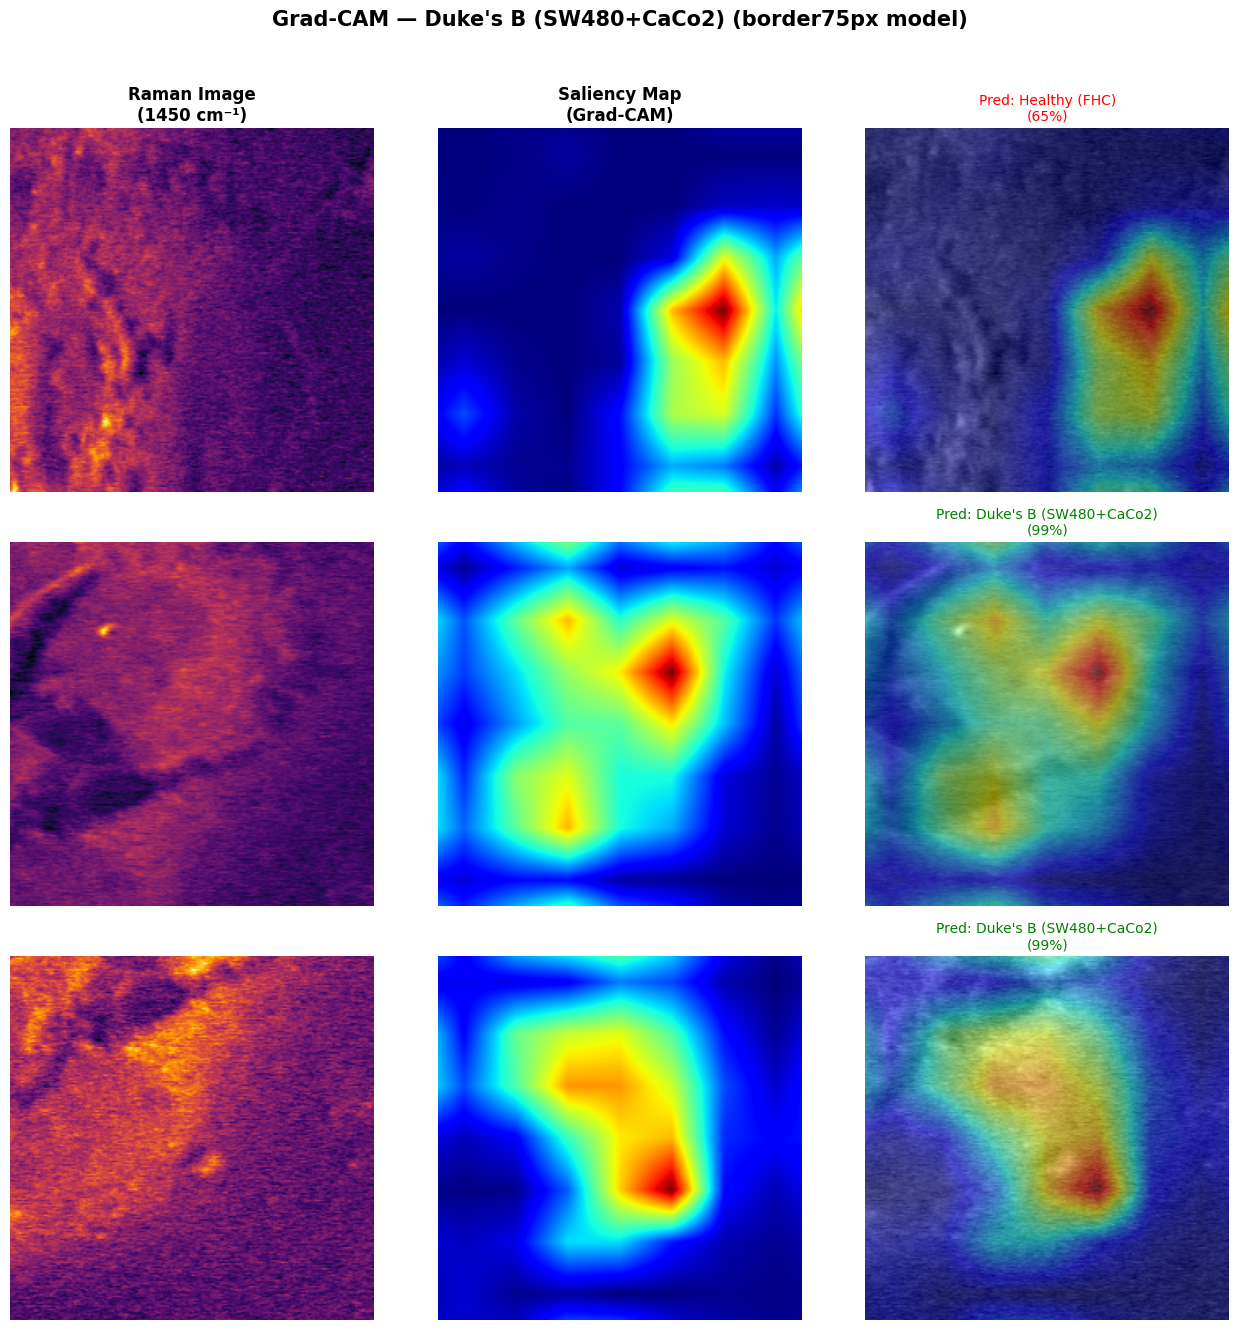

Saved: /users/vvgk0135/raman-project/results/gradcam_3col_2.png


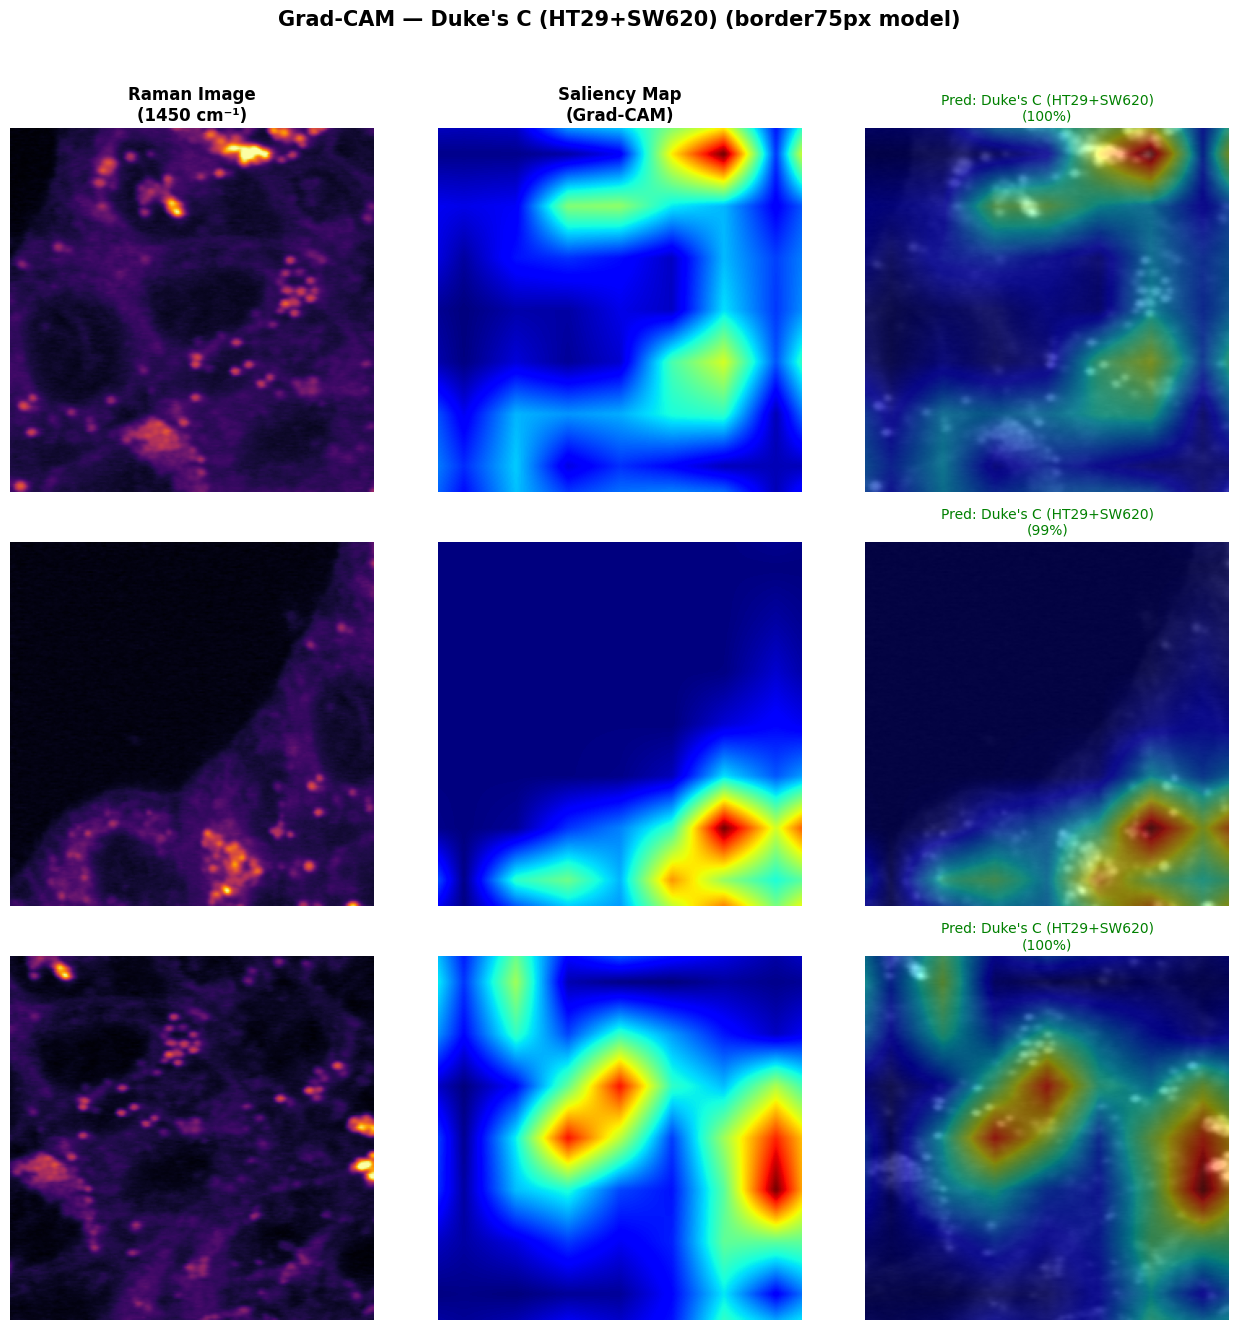

Saved: /users/vvgk0135/raman-project/results/gradcam_3col_3.png

✅ All 4 Grad-CAM figures saved including FHC!


In [10]:
for stage_idx in range(4):
    stage_name = class_names[stage_idx]
    cells      = samples_per_class[stage_idx]

    fig, axes = plt.subplots(3, 3, figsize=(13, 13))
    fig.suptitle(f'Grad-CAM — {stage_name} (border75px model)',
                 fontsize=15, fontweight='bold', y=1.02)

    col_titles = ['Raman Image\n(1450 cm⁻¹)', 'Saliency Map\n(Grad-CAM)', 'Overlay']
    for j, title in enumerate(col_titles):
        axes[0][j].set_title(title, fontsize=12, fontweight='bold')

    for row, inputs in enumerate(cells):
        inputs_dev = inputs.to(device)

        with torch.no_grad():
            outputs    = model(inputs_dev)
            pred_idx   = outputs.argmax(1).item()
            confidence = torch.softmax(outputs, dim=1)[0, pred_idx].item()

        cam         = gradcam.generate(inputs_dev, pred_idx)
        cam_resized = resize(cam, (224, 224), anti_aliasing=True)

        ch_img = inputs[0, 0, :, :].detach().cpu().numpy()
        ch_img = (ch_img - ch_img.min()) / (ch_img.max() - ch_img.min() + 1e-8)

        # Column 1 — Raman image
        axes[row][0].imshow(ch_img, cmap='inferno')
        axes[row][0].axis('off')
        axes[row][0].set_ylabel(f'Cell {row+1}', fontsize=10, fontweight='bold')

        # Column 2 — Saliency map
        axes[row][1].imshow(cam_resized, cmap='jet')
        axes[row][1].axis('off')

        # Column 3 — Overlay
        pred_name = class_names[pred_idx]
        color     = 'green' if pred_idx == stage_idx else 'red'
        axes[row][2].imshow(ch_img, cmap='gray')
        axes[row][2].imshow(cam_resized, cmap='jet', alpha=0.5)
        axes[row][2].set_title(f'Pred: {pred_name}\n({confidence:.0%})',
                               fontsize=10, color=color)
        axes[row][2].axis('off')

    # Add FHC correlation warning if applicable
    if stage_idx == 0:
        fig.text(0.5, -0.02,
                 'Note: FHC heatmap pairwise correlation = 0.63 (vs 0.15-0.27 for cancer classes)\n'
                 'Heatmaps may reflect data scarcity (28 cells) rather than specific biological features.',
                 ha='center', fontsize=10, color='darkorange',
                 style='italic', wrap=True)

    plt.tight_layout()
    save_path = f'/users/vvgk0135/raman-project/results/gradcam_3col_{stage_idx}.png'
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("\n✅ All 4 Grad-CAM figures saved including FHC!")

In [11]:
import os
from collections import defaultdict

# Print exactly which files go to train, val, test
# so we can verify sessions are never mixed
train_s, val_s, test_s = acquisition_based_split(root_75px, class_map)

print("ACQUISITION SPLIT VERIFICATION")
print("="*60)

for split_name, split_data in [("TRAIN", train_s), ("VAL", val_s), ("TEST", test_s)]:
    print(f"\n{split_name} SET ({len(split_data)} cells):")
    
    # Group by cell line and area
    groups = defaultdict(int)
    for path, label in split_data:
        fname = os.path.basename(path)
        # Extract cell line and area from filename
        parts = fname.split('_')
        cell_line = parts[0]
        area = 'area1'
        for part in parts:
            if 'area' in part.lower():
                area = part
                break
        groups[(cell_line, area)] += 1
    
    for (cell_line, area), count in sorted(groups.items()):
        print(f"  {cell_line} — {area}: {count} cells")

ACQUISITION SPLIT VERIFICATION

TRAIN SET (732 cells):
  CaCo2 — area1: 37 cells
  FHC — area3: 14 cells
  HCT116 — area1: 128 cells
  HCT116 — area2: 135 cells
  HT29 — area1: 139 cells
  SW480 — area1: 50 cells
  SW620 — area2: 229 cells

VAL SET (138 cells):
  CaCo2 — area2: 12 cells
  FHC — area4: 7 cells
  HCT116 — area3: 52 cells
  HT29 — area2: 67 cells

TEST SET (140 cells):
  CaCo2 — area2: 12 cells
  FHC — area4: 7 cells
  HCT116 — area3: 53 cells
  HT29 — area2: 68 cells


In [12]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

class RamanCellDatasetMeta(Dataset):
    def __init__(self, root_dir, size_metadata, samples=None, augment=False,
                 zero_metadata=False):
        self.augment       = augment
        self.zero_metadata = zero_metadata
        self.size_metadata = size_metadata
        self.samples = [s[0] for s in samples]
        self.labels  = [s[1] for s in samples]

        all_sizes = np.array(list(size_metadata.values()))
        self.size_mean = all_sizes.mean(axis=0)
        self.size_std  = all_sizes.std(axis=0)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path = self.samples[idx]
        cell = np.load(path).astype(np.float32)

        for ch in range(cell.shape[0]):
            ch_min, ch_max = cell[ch].min(), cell[ch].max()
            if ch_max > ch_min:
                cell[ch] = (cell[ch] - ch_min) / (ch_max - ch_min)

        if self.augment:
            if random.random() > 0.5:
                cell = cell[:, ::-1, :].copy()
            if random.random() > 0.5:
                cell = cell[:, :, ::-1].copy()
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                cell = np.rot90(cell, k=k, axes=(1, 2)).copy()
            if random.random() > 0.5:
                noise_stds = [0.0562, 0.0458, 0.0486, 0.0783]
                noise = np.zeros_like(cell)
                for ch in range(4):
                    noise[ch] = np.random.normal(
                        0, noise_stds[ch], cell[ch].shape).astype(np.float32)
                cell = np.clip(cell + noise, 0, 1)

        filename = os.path.basename(path)
        if self.zero_metadata:
            # Experiment 3 — pass zeros instead of real size values
            size_norm = np.zeros(3, dtype=np.float32)
        else:
            size_raw  = np.array(self.size_metadata.get(filename, [0,0,0]),
                                  dtype=np.float32)
            size_norm = (size_raw - self.size_mean) / (self.size_std + 1e-8)

        return torch.tensor(cell), torch.tensor(size_norm, dtype=torch.float32), self.labels[idx]


class RamanResNet50Hybrid(nn.Module):
    def __init__(self, num_classes=4, meta_dim=3):
        super(RamanResNet50Hybrid, self).__init__()

        self.image_branch = resnet50(weights=ResNet50_Weights.DEFAULT)
        original_conv = self.image_branch.conv1
        self.image_branch.conv1 = nn.Conv2d(4, 64, kernel_size=7,
                                             stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.image_branch.conv1.weight[:, :3] = original_conv.weight
            self.image_branch.conv1.weight[:, 3:4] = original_conv.weight.mean(
                dim=1, keepdim=True)
        image_feat_dim = self.image_branch.fc.in_features
        self.image_branch.fc = nn.Identity()

        self.meta_branch = nn.Sequential(
            nn.Linear(meta_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(image_feat_dim + 16, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, size_meta):
        img_features  = self.image_branch(image)
        meta_features = self.meta_branch(size_meta)
        combined      = torch.cat([img_features, meta_features], dim=1)
        return self.classifier(combined)


def train_hybrid(root_dir, size_metadata, zero_metadata=False, n_runs=3):
    train_s, val_s, test_s = acquisition_based_split(root_dir, class_map)

    train_ds = RamanCellDatasetMeta(root_dir, size_metadata,
                                     samples=train_s, augment=True,
                                     zero_metadata=zero_metadata)
    val_ds   = RamanCellDatasetMeta(root_dir, size_metadata,
                                     samples=val_s, augment=False,
                                     zero_metadata=zero_metadata)
    test_ds  = RamanCellDatasetMeta(root_dir, size_metadata,
                                     samples=test_s, augment=False,
                                     zero_metadata=zero_metadata)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4)
    val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4)
    test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4)

    counts  = [train_ds.labels.count(i) + val_ds.labels.count(i) +
               test_ds.labels.count(i) for i in range(4)]
    total   = sum(counts)
    weights = torch.tensor([total/(4*c) if c>0 else 0 for c in counts],
                            dtype=torch.float32).to(device)

    val_accs = []
    best_overall_acc = 0
    best_wts = None

    for run in range(n_runs):
        model_h = RamanResNet50Hybrid(num_classes=4).to(device)
        criterion = nn.CrossEntropyLoss(weight=weights)
        optimizer = Adam(model_h.parameters(), lr=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=50)

        best_val_acc = 0
        best_model_wts = copy.deepcopy(model_h.state_dict())
        patience = 0

        for epoch in range(50):
            model_h.train()
            for images, sizes, labels in train_loader:
                images = images.to(device)
                sizes  = sizes.to(device)
                labels = labels.to(device) if isinstance(labels, torch.Tensor) \
                         else torch.tensor(labels).to(device)
                optimizer.zero_grad()
                outputs = model_h(images, sizes)
                loss    = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            model_h.eval()
            correct = 0
            with torch.no_grad():
                for images, sizes, labels in val_loader:
                    images = images.to(device)
                    sizes  = sizes.to(device)
                    labels = labels.to(device) if isinstance(labels, torch.Tensor) \
                             else torch.tensor(labels).to(device)
                    outputs = model_h(images, sizes)
                    correct += outputs.argmax(1).eq(labels).sum().item()
            val_acc = 100. * correct / len(val_ds)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_wts = copy.deepcopy(model_h.state_dict())
                patience = 0
            else:
                patience += 1
            if patience >= 7:
                break
            scheduler.step()

        val_accs.append(best_val_acc)
        if best_val_acc > best_overall_acc:
            best_overall_acc = best_val_acc
            best_wts = copy.deepcopy(best_model_wts)
        print(f"  Run {run+1}: val={best_val_acc:.2f}%")

    # Test evaluation
    model_h.load_state_dict(best_wts)
    model_h.eval()
    all_preds, all_labels_list = [], []
    with torch.no_grad():
        for images, sizes, labels in test_loader:
            images = images.to(device)
            sizes  = sizes.to(device)
            labels_t = labels.to(device) if isinstance(labels, torch.Tensor) \
                       else torch.tensor(labels).to(device)
            outputs = model_h(images, sizes)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_list.extend(labels_t.cpu().numpy())

    from sklearn.metrics import f1_score
    test_acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels_list))
    macro_f1 = f1_score(all_labels_list, all_preds, average='macro')

    return {
        "val_mean": np.mean(val_accs),
        "val_std":  np.std(val_accs),
        "test_acc": test_acc,
        "macro_f1": macro_f1
    }


print("✅ Hybrid model and training function ready!")

✅ Hybrid model and training function ready!


In [13]:
from skimage.measure import regionprops
import tifffile

pixel_size_um = 0.1114

def build_size_metadata(dataset_root, class_map, cell_line_paths, ht29_path_info):
    metadata = {}
    stage_map = {'FHC':0,'HCT116':1,'SW480':2,'CaCo2':2,'HT29':3,'SW620':3}

    for cell_line, rel_path in cell_line_paths.items():
        area_path = os.path.join(dataset_root, rel_path)
        seg_files = [f for f in os.listdir(area_path) if f.endswith('_seg.npy')]

        for seg_file in seg_files:
            mask = np.load(os.path.join(area_path, seg_file),
                           allow_pickle=True).item()['masks']
            regions = regionprops(mask)

            seg_lower = seg_file.lower()
            if   'area 1' in seg_lower or 'area1' in seg_lower: area_num = '1'
            elif 'area 2' in seg_lower or 'area2' in seg_lower: area_num = '2'
            elif 'area 3' in seg_lower or 'area3' in seg_lower: area_num = '3'
            elif 'area 4' in seg_lower or 'area4' in seg_lower: area_num = '4'
            else:                                                area_num = '1'

            for region in regions:
                r0, c0, r1, c1 = region.bbox
                width_um  = (c1 - c0) * pixel_size_um
                height_um = (r1 - r0) * pixel_size_um
                area_um2  = region.area * (pixel_size_um ** 2)
                filename  = f"{cell_line}_area{area_num}_cell{region.label:03d}.npy"
                metadata[filename] = [width_um, height_um, area_um2]

    # HT29 separately
    ht29_full_path = os.path.join(dataset_root, ht29_path_info['path'])
    for seg_file in ht29_path_info['segs']:
        mask = np.load(os.path.join(ht29_full_path, seg_file),
                       allow_pickle=True).item()['masks']
        regions = regionprops(mask)

        seg_lower = seg_file.lower()
        if   'area 1' in seg_lower or 'area1' in seg_lower: area_num = '1'
        elif 'area 2' in seg_lower or 'area2' in seg_lower: area_num = '2'
        else:                                                area_num = '1'

        for region in regions:
            r0, c0, r1, c1 = region.bbox
            width_um  = (c1 - c0) * pixel_size_um
            height_um = (r1 - r0) * pixel_size_um
            area_um2  = region.area * (pixel_size_um ** 2)
            filename  = f"HT29_area{area_num}_cell{region.label:03d}.npy"
            metadata[filename] = [width_um, height_um, area_um2]

    return metadata


cell_line_paths = {
    "CaCo2":  "CaCo2/2025-05-07 CaCo2 in media",
    "FHC":    "FHC/2025-03-14 FHC in media",
    "HCT116": "HCT116/2025-02-14 HCT116 in media",
    "SW480":  "SW480/2025-02-14 - SW480 in media",
    "SW620":  "SW620/2025-03-21 SW620 in media",
}

ht29_info = {
    "path": "HT29/2025-05-14 HT29",
    "segs": [
        "2025-05-14 - HT29_Area 1 - SRS 2850, 2935, 1900, 1660, 1455, 790_ch01_seg.npy",
        "2025-05-14 - HT29_Area 2 - SRS 2850, 2935, 3350, 1900, 1660, 1455, 790_ch01_seg.npy",
    ]
}

size_metadata = build_size_metadata(
    dataset_root, class_map, cell_line_paths, ht29_info
)
print(f"✅ Metadata built for {len(size_metadata)} cells")

# Now run all 3 hybrid ablation experiments
hybrid_results = {}

# Experiment 1 — Hybrid on baseline (0px border, real background)
print(f"\n{'='*60}")
print("EXPERIMENT 1 — Hybrid on baseline (0px border)")
print(f"{'='*60}")
hybrid_results['hybrid_0px'] = train_hybrid(
    root_dir      = "/users/vvgk0135/raman-project/data/extracted_cells_border0px",
    size_metadata = size_metadata,
    zero_metadata = False,
    n_runs        = 3
)
r = hybrid_results['hybrid_0px']
print(f"Val: {r['val_mean']:.2f}%±{r['val_std']:.2f}% | Test: {r['test_acc']:.2f}% | F1: {r['macro_f1']:.3f}")

# Experiment 2 — Hybrid on 75px (already done but rerun with fixed seed)
print(f"\n{'='*60}")
print("EXPERIMENT 2 — Hybrid on 75px border")
print(f"{'='*60}")
hybrid_results['hybrid_75px'] = train_hybrid(
    root_dir      = "/users/vvgk0135/raman-project/data/extracted_cells_border75px",
    size_metadata = size_metadata,
    zero_metadata = False,
    n_runs        = 3
)
r = hybrid_results['hybrid_75px']
print(f"Val: {r['val_mean']:.2f}%±{r['val_std']:.2f}% | Test: {r['test_acc']:.2f}% | F1: {r['macro_f1']:.3f}")

# Experiment 3 — Hybrid on 75px but metadata zeroed out
print(f"\n{'='*60}")
print("EXPERIMENT 3 — Hybrid on 75px, metadata zeroed")
print(f"{'='*60}")
hybrid_results['hybrid_75px_zero'] = train_hybrid(
    root_dir      = "/users/vvgk0135/raman-project/data/extracted_cells_border75px",
    size_metadata = size_metadata,
    zero_metadata = True,
    n_runs        = 3
)
r = hybrid_results['hybrid_75px_zero']
print(f"Val: {r['val_mean']:.2f}%±{r['val_std']:.2f}% | Test: {r['test_acc']:.2f}% | F1: {r['macro_f1']:.3f}")

# Final summary
print(f"\n\n{'='*70}")
print("HYBRID ABLATION SUMMARY")
print(f"{'='*70}")
print(f"{'Experiment':<30} {'Val Acc':>12} {'Test Acc':>10} {'Macro F1':>10}")
print("-"*65)

# Also include image-only baselines for comparison
baselines = {
    'image_only_0px':  {'val_mean':85.75, 'val_std':1.81, 'test_acc':81.43, 'macro_f1':0.817},
    'image_only_75px': {'val_mean':95.89, 'val_std':1.23, 'test_acc':95.00, 'macro_f1':0.956},
}

all_results = {**baselines, **hybrid_results}
labels = {
    'image_only_0px':    'Image only — 0px border',
    'hybrid_0px':        'Hybrid (image+size) — 0px',
    'image_only_75px':   'Image only — 75px border',
    'hybrid_75px':       'Hybrid (image+size) — 75px',
    'hybrid_75px_zero':  'Hybrid (zeroed meta) — 75px',
}

for key, label in labels.items():
    r = all_results[key]
    print(f"{label:<30} {r['val_mean']:>8.2f}±{r['val_std']:<3.1f} {r['test_acc']:>9.2f}% {r['macro_f1']:>10.3f}")

✅ Metadata built for 1010 cells

EXPERIMENT 1 — Hybrid on baseline (0px border)
  Run 1: val=85.51%
  Run 2: val=86.96%
  Run 3: val=88.41%
Val: 86.96%±1.18% | Test: 77.86% | F1: 0.741

EXPERIMENT 2 — Hybrid on 75px border
  Run 1: val=98.55%
  Run 2: val=97.10%
  Run 3: val=96.38%
Val: 97.34%±0.90% | Test: 91.43% | F1: 0.921

EXPERIMENT 3 — Hybrid on 75px, metadata zeroed
  Run 1: val=97.10%
Val: 97.10%±0.00% | Test: 91.43% | F1: 0.928


HYBRID ABLATION SUMMARY
Experiment                          Val Acc   Test Acc   Macro F1
-----------------------------------------------------------------
Image only — 0px border           85.75±1.8     81.43%      0.817
Hybrid (image+size) — 0px         86.96±1.2     77.86%      0.741
Image only — 75px border          95.89±1.2     95.00%      0.956
Hybrid (image+size) — 75px        97.34±0.9     91.43%      0.921
Hybrid (zeroed meta) — 75px       97.10±0.0     91.43%      0.928
